# Practical 2 — Dataset Handling: Loading, Preprocessing & Visualizing MNIST and CIFAR-10

**Objectives:**
- Load MNIST and CIFAR-10 datasets using Keras
- Preprocess: normalize, reshape, one-hot encode
- Visualize: samples, class distributions, pixel statistics
- Compare both datasets

**Runtime:** Go to `Runtime → Change runtime type → GPU` before running

---
## SECTION 1 — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

# Pretty print settings
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

print('TensorFlow version :', tf.__version__)
print('NumPy version      :', np.__version__)
print('All libraries imported successfully ✅')

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries imported successfully ✅


---
## SECTION 2 — Load MNIST Dataset

In [ ]:
# ── Load MNIST ───────────────────────────────────────────────
# Downloads automatically (~11 MB) on first run
(mnist_X_train, mnist_y_train), (mnist_X_test, mnist_y_test) = mnist.load_data()

print('='*45)
print('  MNIST DATASET — RAW (before preprocessing)')
print('='*45)
print(f'  Training images shape : {mnist_X_train.shape}')
print(f'  Training labels shape : {mnist_y_train.shape}')
print(f'  Test images shape     : {mnist_X_test.shape}')
print(f'  Test labels shape     : {mnist_y_test.shape}')
print(f'  Pixel value range     : {mnist_X_train.min()} to {mnist_X_train.max()}')
print(f'  Data type             : {mnist_X_train.dtype}')
print(f'  Unique classes        : {np.unique(mnist_y_train)}')
print(f'  Total samples         : {len(mnist_X_train) + len(mnist_X_test):,}')

  MNIST DATASET — RAW (before preprocessing)
  Training images shape : (60000, 28, 28)
  Training labels shape : (60000,)
  Test images shape     : (10000, 28, 28)
  Test labels shape     : (10000,)
  Pixel value range     : 0 to 255
  Data type             : uint8
  Unique classes        : [0 1 2 3 4 5 6 7 8 9]
  Total samples         : 70,000


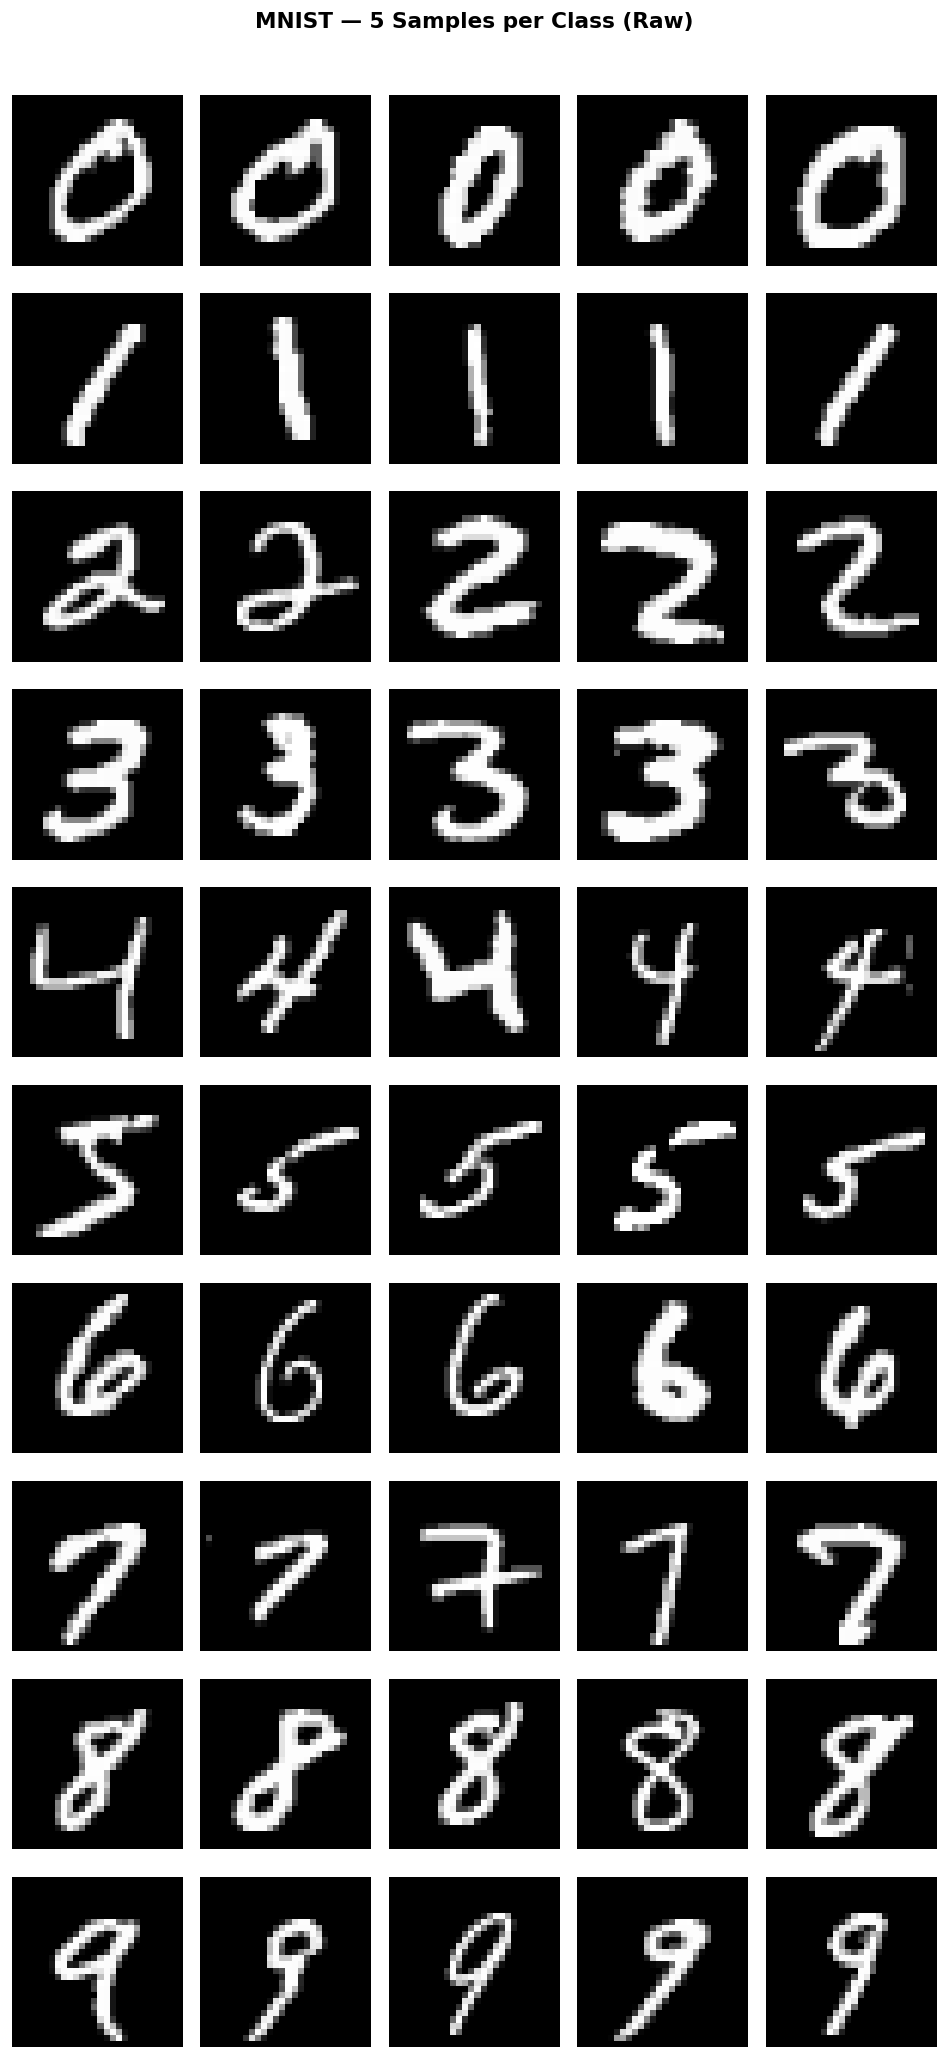

Saved: mnist_samples.png


In [ ]:
# Visualize raw MNIST samples — 5 samples per class
mnist_classes = list(range(10))
fig, axes = plt.subplots(10, 5, figsize=(8, 17))
fig.suptitle('MNIST — 5 Samples per Class (Raw)', fontsize=13, fontweight='bold', y=1.01)

for cls in mnist_classes:
    idxs = np.where(mnist_y_train == cls)[0][:5]
    for j, idx in enumerate(idxs):
        ax = axes[cls][j]
        ax.imshow(mnist_X_train[idx], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'Digit {cls}', rotation=0, labelpad=35,
                          fontsize=9, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mnist_samples.png')

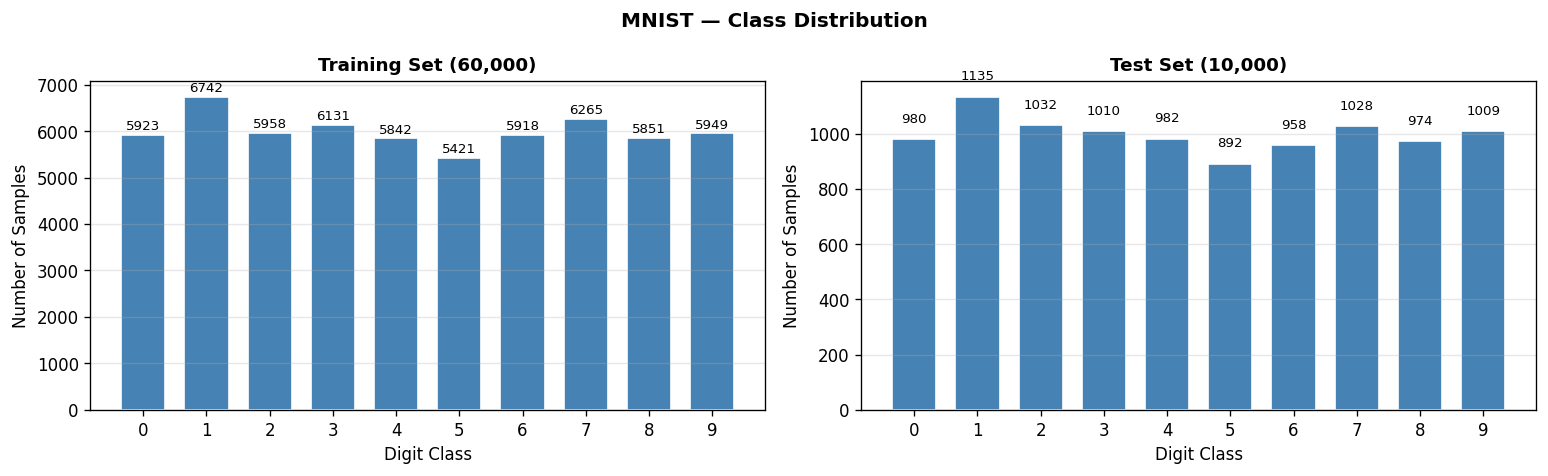

In [ ]:
# MNIST class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('MNIST — Class Distribution', fontsize=12, fontweight='bold')

for ax, split, labels, title in [
    (axes[0], mnist_y_train, mnist_y_train, 'Training Set (60,000)'),
    (axes[1], mnist_y_test,  mnist_y_test,  'Test Set (10,000)')
]:
    unique, counts = np.unique(split, return_counts=True)
    bars = ax.bar(unique, counts, color='steelblue', edgecolor='white', width=0.7)
    ax.set_xticks(unique)
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('Number of Samples')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('mnist_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Label for this sample : 5
Image shape           : (28, 28)

Pixel values (28x28 grid):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  3

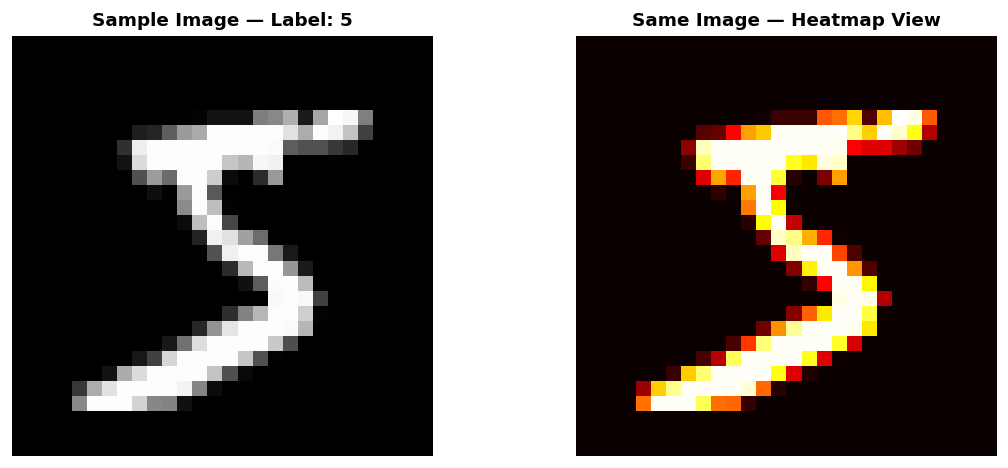

In [ ]:
# Show one sample as a raw pixel array
sample = mnist_X_train[0]
print(f'Label for this sample : {mnist_y_train[0]}')
print(f'Image shape           : {sample.shape}')
print(f'\nPixel values (28x28 grid):')
print(sample)

# Visual of that sample
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(sample, cmap='gray')
ax1.set_title(f'Sample Image — Label: {mnist_y_train[0]}')
ax1.axis('off')

ax2.imshow(sample, cmap='hot')
ax2.set_title('Same Image — Heatmap View')
ax2.axis('off')
plt.tight_layout()
plt.show()

---
## SECTION 3 — Load CIFAR-10 Dataset

In [ ]:
import os
import pickle
import sys
import tarfile

# Function to load a single CIFAR-10 batch from local files
def load_cifar_batch(file_path):
    with open(file_path, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    X = dict[b'data']
    y = dict[b'labels']
    # Reshape from (N, 3*32*32) to (N, 32, 32, 3)
    X = X.reshape(X.shape[0], 3, 32, 32).transpose(0, 2, 3, 1)
    return X, np.array(y)

# Manual loading function if automatic download fails
def load_cifar10_from_local(path='/content/cifar-10-batches-py'):
    print(f"Attempting to load CIFAR-10 from local path: {path}")
    X_train_batches, y_train_batches = [], []
    for i in range(1, 6):
        batch_path = os.path.join(path, f'data_batch_{i}')
        if not os.path.exists(batch_path):
            raise FileNotFoundError(f"Batch file not found: {batch_path}. Please ensure CIFAR-10 is extracted correctly.")
        X, y = load_cifar_batch(batch_path)
        X_train_batches.append(X)
        y_train_batches.append(y)
    cifar_X_train = np.concatenate(X_train_batches)
    cifar_y_train = np.concatenate(y_train_batches)

    test_batch_path = os.path.join(path, 'test_batch')
    if not os.path.exists(test_batch_path):
        raise FileNotFoundError(f"Test batch file not found: {test_batch_path}. Please ensure CIFAR-10 is extracted correctly.")
    cifar_X_test, cifar_y_test = load_cifar_batch(test_batch_path)

    return (cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test)

In [ ]:
# ── Load CIFAR-10 ────────────────────────────────────────────
# Downloads automatically (~163 MB) on first run

try:
    (cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = cifar10.load_data()
    print("CIFAR-10 dataset loaded successfully using Keras's built-in function.")
except Exception as e:
    print(f"Failed to load CIFAR-10 using keras.datasets.cifar10.load_data(): {e}")
    print("This is often due to '503 Service Unavailable' from the dataset host.")
    print("Attempting to load from local files. You may need to manually upload 'cifar-10-python.tar.gz' to /content/")
    local_tar_path = '/content/cifar-10-python.tar.gz'
    extracted_dir  = '/content/cifar-10-batches-py'

    if not os.path.exists(local_tar_path):
        print(f"WARNING: '{local_tar_path}' not found. Please upload the CIFAR-10 tar.gz file manually if this persists.")
        sys.exit("Manual upload required for CIFAR-10 dataset.")
    else:
        print(f"Found local tar.gz: '{local_tar_path}'. Extracting...")
        with tarfile.open(local_tar_path, 'r:gz') as tar:
            tar.extractall(path='/content')
        print("Extraction complete. Loading data from extracted files...")
        (cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = load_cifar10_from_local(extracted_dir)
        print("CIFAR-10 dataset loaded successfully from local files.")

# Class names
cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

# Flatten label arrays from (N,1) to (N,) - only if they are not already (N,)
if cifar_y_train.ndim > 1:
    cifar_y_train = cifar_y_train.flatten()
if cifar_y_test.ndim > 1:
    cifar_y_test  = cifar_y_test.flatten()

print('='*47)
print('  CIFAR-10 DATASET — RAW (before preprocessing)')
print('='*47)
print(f'  Training images shape : {cifar_X_train.shape}')
print(f'  Training labels shape : {cifar_y_train.shape}')
print(f'  Test images shape     : {cifar_X_test.shape}')
print(f'  Test labels shape     : {cifar_y_test.shape}')
print(f'  Pixel value range     : {cifar_X_train.min()} to {cifar_X_train.max()}')
print(f'  Data type             : {cifar_X_train.dtype}')
print(f'  Classes               : {cifar_class_names}')
print(f'  Total samples         : {len(cifar_X_train) + len(cifar_X_test):,}')

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Failed to load CIFAR-10 using keras.datasets.cifar10.load_data(): URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable
This is often due to '503 Service Unavailable' from the dataset host.
Attempting to load from local files. You may need to manually upload 'cifar-10-python.tar.gz' to /content/
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/file_utils.py", line 354, in get_file
    urlretrieve(origin, download_target, DLProgbar())
  File "/usr/lib/python3.12/urllib/request.py", line 240, in urlretrieve
    with contextlib.closing(urlopen(url, data)) as fp:
                            ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/urllib/request.py", line 215, in urlopen
    return opener.open(url, data, timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/urllib/request.py", line 521, in open
    response = meth(req, response)
               ^^^^^^^^^^^^^^^

TypeError: object of type 'NoneType' has no len()

# ── Load CIFAR-10 ────────────────────────────────────────────
# Downloads automatically (~163 MB) on first run

import tarfile

with tarfile.open('/content/cifar-10-python.tar.gz', 'r:gz') as tar:
    tar.extractall(path='/content')


(cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = cifar10.load_data()

# Class names
cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

# Flatten label arrays from (N,1) to (N,)
cifar_y_train = cifar_y_train.flatten()
cifar_y_test  = cifar_y_test.flatten()

print('='*47)
print('  CIFAR-10 DATASET — RAW (before preprocessing)')
print('='*47)
print(f'  Training images shape : {cifar_X_train.shape}')
print(f'  Training labels shape : {cifar_y_train.shape}')
print(f'  Test images shape     : {cifar_X_test.shape}')
print(f'  Test labels shape     : {cifar_y_test.shape}')
print(f'  Pixel value range     : {cifar_X_train.min()} to {cifar_X_train.max()}')
print(f'  Data type             : {cifar_X_train.dtype}')
print(f'  Classes               : {cifar_class_names}')
print(f'  Total samples         : {len(cifar_X_train) + len(cifar_X_test):,}')

In [ ]:

# Visualize CIFAR-10 samples — 5 per class
fig, axes = plt.subplots(10, 5, figsize=(8, 17))
fig.suptitle('CIFAR-10 — 5 Samples per Class (Raw)', fontsize=13, fontweight='bold', y=1.01)

for cls in range(10):
    idxs = np.where(cifar_y_train == cls)[0][:5]
    for j, idx in enumerate(idxs):
        ax = axes[cls][j]
        ax.imshow(cifar_X_train[idx])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(cifar_class_names[cls], rotation=0, labelpad=50,
                          fontsize=9, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cifar10_samples.png')

In [ ]:
# CIFAR-10 class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('CIFAR-10 — Class Distribution', fontsize=12, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, split, title in [
    (axes[0], cifar_y_train, 'Training Set (50,000)'),
    (axes[1], cifar_y_test,  'Test Set (10,000)')
]:
    unique, counts = np.unique(split, return_counts=True)
    bars = ax.bar(unique, counts, color=colors, edgecolor='white', width=0.7)
    ax.set_xticks(unique)
    ax.set_xticklabels(cifar_class_names, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Number of Samples')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(count), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('cifar10_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CIFAR-10 — show R, G, B channels separately for one image
sample_img   = cifar_X_train[0]
sample_label = cifar_class_names[cifar_y_train[0]]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle(f'CIFAR-10 RGB Channel Breakdown — Class: {sample_label}',
             fontsize=12, fontweight='bold')

axes[0].imshow(sample_img)
axes[0].set_title('Original (RGB)')
axes[0].axis('off')

channel_names  = ['Red Channel', 'Green Channel', 'Blue Channel']
channel_colors = ['Reds', 'Greens', 'Blues']

for i, (name, cmap) in enumerate(zip(channel_names, channel_colors)):
    axes[i+1].imshow(sample_img[:, :, i], cmap=cmap)
    axes[i+1].set_title(name)
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('cifar10_rgb_channels.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 4 — Preprocessing MNIST

In [ ]:
# ── MNIST Preprocessing ──────────────────────────────────────

# Step 1: Normalize pixel values from (0-255) to (0.0-1.0)
mnist_X_train_norm = mnist_X_train.astype('float32') / 255.0
mnist_X_test_norm  = mnist_X_test.astype('float32')  / 255.0

# Step 2: Reshape for CNN — add channel dimension (28,28) → (28,28,1)
mnist_X_train_cnn = mnist_X_train_norm.reshape(-1, 28, 28, 1)
mnist_X_test_cnn  = mnist_X_test_norm.reshape(-1, 28, 28, 1)

# Step 3: Flatten for MLP — (28,28) → (784,)
mnist_X_train_mlp = mnist_X_train_norm.reshape(-1, 784)
mnist_X_test_mlp  = mnist_X_test_norm.reshape(-1, 784)

# Step 4: One-hot encode labels
mnist_y_train_ohe = to_categorical(mnist_y_train, num_classes=10)
mnist_y_test_ohe  = to_categorical(mnist_y_test,  num_classes=10)

print('='*55)
print('  MNIST — AFTER PREPROCESSING')
print('='*55)
print(f'  Normalized pixel range    : {mnist_X_train_norm.min():.1f} to {mnist_X_train_norm.max():.1f}')
print(f'  CNN input shape           : {mnist_X_train_cnn.shape}')
print(f'  MLP input shape (flat)    : {mnist_X_train_mlp.shape}')
print(f'  Label before OHE          : {mnist_y_train[0]}')
print(f'  Label after OHE           : {mnist_y_train_ohe[0]}')
print(f'  OHE label shape           : {mnist_y_train_ohe.shape}')

In [ ]:
# Visualize effect of normalization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('MNIST — Effect of Normalization on Pixel Values', fontsize=12, fontweight='bold')

# Raw pixels histogram
axes[0].hist(mnist_X_train.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Pixel Values (0–255)')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Normalized pixels histogram
axes[1].hist(mnist_X_train_norm.flatten(), bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Normalized Pixel Values (0.0–1.0)')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

# Side-by-side image comparison
idx = 7
axes[2].imshow(np.hstack([
    np.pad(mnist_X_train[idx], 2),
    np.pad((mnist_X_train_norm[idx]*255).astype(np.uint8), 2)
]), cmap='gray')
axes[2].set_title('Raw (left) vs Normalized (right)\n(look identical — range changes, not content)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('mnist_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 5 — Preprocessing CIFAR-10

In [ ]:
# ── CIFAR-10 Preprocessing ───────────────────────────────────

# Step 1: Normalize
cifar_X_train_norm = cifar_X_train.astype('float32') / 255.0
cifar_X_test_norm  = cifar_X_test.astype('float32')  / 255.0

# Step 2: Shape already (N,32,32,3) — ready for CNN
# For MLP: flatten to (N, 3072)
cifar_X_train_mlp = cifar_X_train_norm.reshape(-1, 32*32*3)
cifar_X_test_mlp  = cifar_X_test_norm.reshape(-1, 32*32*3)

# Step 3: One-hot encode
cifar_y_train_ohe = to_categorical(cifar_y_train, num_classes=10)
cifar_y_test_ohe  = to_categorical(cifar_y_test,  num_classes=10)

print('='*55)
print('  CIFAR-10 — AFTER PREPROCESSING')
print('='*55)
print(f'  Normalized pixel range    : {cifar_X_train_norm.min():.1f} to {cifar_X_train_norm.max():.1f}')
print(f'  CNN input shape           : {cifar_X_train_norm.shape}')
print(f'  MLP input shape (flat)    : {cifar_X_train_mlp.shape}')
print(f'  Label before OHE          : {cifar_y_train[0]} ({cifar_class_names[cifar_y_train[0]]})')
print(f'  Label after OHE           : {cifar_y_train_ohe[0]}')
print(f'  OHE label shape           : {cifar_y_train_ohe.shape}')

In [ ]:
# CIFAR-10 pixel distribution per channel
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('CIFAR-10 — Pixel Distribution per RGB Channel (Before vs After Normalization)',
             fontsize=11, fontweight='bold')

channel_names  = ['Red', 'Green', 'Blue']
channel_colors = ['tomato', 'mediumseagreen', 'steelblue']

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    # Before
    axes[0][i].hist(cifar_X_train[:,:,:,i].flatten(), bins=50,
                    color=color, alpha=0.8, edgecolor='white')
    axes[0][i].set_title(f'{name} — Raw (0–255)')
    axes[0][i].set_xlabel('Pixel Value')
    axes[0][i].set_ylabel('Frequency')
    axes[0][i].grid(alpha=0.3)

    # After
    axes[1][i].hist(cifar_X_train_norm[:,:,:,i].flatten(), bins=50,
                    color=color, alpha=0.8, edgecolor='white')
    axes[1][i].set_title(f'{name} — Normalized (0.0–1.0)')
    axes[1][i].set_xlabel('Pixel Value')
    axes[1][i].set_ylabel('Frequency')
    axes[1][i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cifar10_channel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 6 — Advanced Visualizations

In [ ]:
# Mean image per class — what does the 'average' of each class look like?

# MNIST mean images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle('MNIST — Mean Image per Class', fontsize=12, fontweight='bold')
for cls in range(10):
    mask       = mnist_y_train == cls
    mean_image = mnist_X_train_norm[mask].mean(axis=0)
    axes[cls].imshow(mean_image, cmap='gray')
    axes[cls].set_title(str(cls), fontsize=10)
    axes[cls].axis('off')
plt.tight_layout()
plt.savefig('mnist_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()

# CIFAR-10 mean images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle('CIFAR-10 — Mean Image per Class', fontsize=12, fontweight='bold')
for cls in range(10):
    mask       = cifar_y_train == cls
    mean_image = cifar_X_train_norm[mask].mean(axis=0)
    axes[cls].imshow(mean_image)
    axes[cls].set_title(cifar_class_names[cls], fontsize=7, rotation=30)
    axes[cls].axis('off')
plt.tight_layout()
plt.savefig('cifar10_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pixel intensity statistics comparison
stats = {
    'MNIST'    : mnist_X_train_norm,
    'CIFAR-10' : cifar_X_train_norm
}

print('='*55)
print('  PIXEL STATISTICS (after normalization)')
print('='*55)
print(f'  {"Dataset":<12}  {"Mean":>8}  {"Std":>8}  {"Min":>8}  {"Max":>8}')
print('-'*55)
for name, data in stats.items():
    print(f'  {name:<12}  {data.mean():>8.4f}  {data.std():>8.4f}  '
          f'{data.min():>8.4f}  {data.max():>8.4f}')

# Combined histogram comparison
plt.figure(figsize=(10, 4))
plt.hist(mnist_X_train_norm.flatten(),    bins=60, alpha=0.6,
         color='steelblue', label='MNIST', density=True)
plt.hist(cifar_X_train_norm.flatten(),    bins=60, alpha=0.6,
         color='tomato',    label='CIFAR-10', density=True)
plt.title('MNIST vs CIFAR-10 — Normalized Pixel Distribution', fontweight='bold')
plt.xlabel('Pixel Value (normalized)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mnist_vs_cifar_pixels.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 7 — Final Comparison Summary

In [ ]:
# Final dataset comparison table
print('='*65)
print('  MNIST vs CIFAR-10 — COMPLETE COMPARISON')
print('='*65)
print(f'  {"Feature":<28} {"MNIST":>14}  {"CIFAR-10":>14}')
print('-'*65)

rows = [
    ('Image type',          'Grayscale',   'Color (RGB)'),
    ('Image size',          '28 x 28',     '32 x 32'),
    ('Channels',            '1',           '3'),
    ('Training samples',    '60,000',      '50,000'),
    ('Test samples',        '10,000',      '10,000'),
    ('Number of classes',   '10',          '10'),
    ('Pixels per image',    '784',         '3,072'),
    ('Raw pixel range',     '0 – 255',     '0 – 255'),
    ('After normalization', '0.0 – 1.0',   '0.0 – 1.0'),
    ('MLP input size',      '784',         '3,072'),
    ('Difficulty',          'Easy',        'Medium-Hard'),
    ('MLP accuracy',        '~97-98%',     '~45-50%'),
    ('CNN accuracy',        '~99%',        '~70-75%'),
]

for feature, mnist_val, cifar_val in rows:
    print(f'  {feature:<28} {mnist_val:>14}  {cifar_val:>14}')

print('='*65)
print('\nPreprocessing pipeline used for both datasets:')
print('  1. Load  → keras.datasets.mnist / cifar10')
print('  2. Cast  → float32')
print('  3. Scale → divide by 255.0')
print('  4. Shape → (N,28,28,1) for MNIST-CNN | (N,32,32,3) for CIFAR-CNN')
print('  5. OHE   → to_categorical(y, num_classes=10)')

In [ ]:
# Final visual summary — side by side
fig = plt.figure(figsize=(14, 6))
fig.suptitle('MNIST vs CIFAR-10 — Final Visual Comparison', fontsize=13, fontweight='bold')

# MNIST grid
for i in range(10):
    ax = fig.add_subplot(2, 10, i+1)
    idx = np.where(mnist_y_train == i)[0][0]
    ax.imshow(mnist_X_train_norm[idx], cmap='gray')
    ax.set_title(str(i), fontsize=9)
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('MNIST', fontsize=10, fontweight='bold',
                      rotation=0, labelpad=35, va='center')

# CIFAR-10 grid
for i in range(10):
    ax = fig.add_subplot(2, 10, 11+i)
    idx = np.where(cifar_y_train == i)[0][0]
    ax.imshow(cifar_X_train_norm[idx])
    ax.set_title(cifar_class_names[i], fontsize=7, rotation=30)
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('CIFAR-10', fontsize=10, fontweight='bold',
                      rotation=0, labelpad=45, va='center')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll done! ✅  Practical 2 complete.')
print('Files saved: mnist_samples.png, cifar10_samples.png,')
print('  mnist_class_distribution.png, cifar10_class_distribution.png,')
print('  cifar10_rgb_channels.png, mnist_normalization.png,')
print('  cifar10_channel_distribution.png, mnist_mean_images.png,')
print('  cifar10_mean_images.png, mnist_vs_cifar_pixels.png, final_comparison.png')

---
## Key Learnings

| Topic | Observation |
|-------|-------------|
| **MNIST** | Simple, grayscale, easy to classify — ideal for learning |
| **CIFAR-10** | Color, complex backgrounds — realistic challenge |
| **Normalization** | Always divide by 255 — speeds up training significantly |
| **One-Hot Encoding** | Required for categorical_crossentropy loss |
| **CNN shape** | Needs channel dim: (28,28,1) or (32,32,3) |
| **MLP shape** | Needs flat vector: (784,) or (3072,) |
| **Class balance** | Both datasets are perfectly balanced |
| **Mean images** | Reveal what makes each class visually distinct |

---
*Practical 2 complete ✅ — Part of [Deep Learning Portfolio](https://github.com/GauriShinde911/deep-learning-portfolio)*